# Bank Marketing Campaign Analysis

## Problem Statement
**Objective**: Predict whether a client will subscribe to a term deposit based on bank marketing campaign data.

**Business Context**: 
- Banks need to optimize marketing campaigns by targeting likely subscribers
- Reduces marketing costs and improves conversion rates
- Binary classification problem (subscribe vs not subscribe)

**Approach**:
1. **Exploratory Data Analysis (EDA)**: Understand data patterns and relationships
2. **Data Preprocessing**: Clean and prepare features for modeling
3. **Model Building**: Train logistic regression classifier
4. **Evaluation**: Assess model performance with relevant metrics

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests, zipfile, io


from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [79]:
r = requests.get("https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip")

In [80]:
z = zipfile.ZipFile(io.BytesIO(r.content))

In [81]:
z.namelist()

['bank-full.csv', 'bank-names.txt', 'bank.csv']

## Exploratory Data Analysis (EDA)

### Data Loading and Initial Exploration
- Loading bank marketing dataset from UCI repository
- Contains 45,211 records with 16 features
- Target variable: 'y' (whether client subscribed to term deposit)

### Purpose of EDA:
- Identify data quality issues
- Understand feature distributions
- Discover relationships between variables
- Inform preprocessing decisions

In [82]:
df = pd.read_csv(z.open('bank-full.csv'), sep=';')
print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [83]:
df['month'] = pd.to_datetime(df['month'], format='%b').dt.month
df['month']

0         5
1         5
2         5
3         5
4         5
         ..
45206    11
45207    11
45208    11
45209    11
45210    11
Name: month, Length: 45211, dtype: int32

In [84]:
sorted(df['month'].unique())

[np.int32(1),
 np.int32(2),
 np.int32(3),
 np.int32(4),
 np.int32(5),
 np.int32(6),
 np.int32(7),
 np.int32(8),
 np.int32(9),
 np.int32(10),
 np.int32(11),
 np.int32(12)]

In [85]:
# Summary table by month
data_mnth = df.groupby('month').size().reset_index(name='count')
data_mnth.head(12)

,month,count
0,1,1403
1,2,2649
2,3,477
3,4,2932
4,5,13766
5,6,5341
6,7,6895
7,8,6247
8,9,579
9,10,738


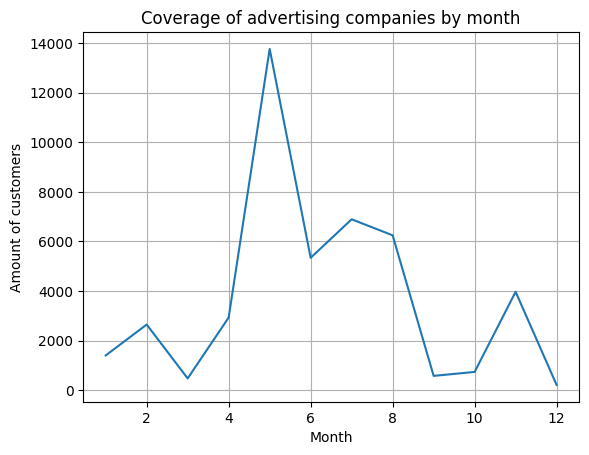

In [86]:
plt.figure()
plt.plot(data_mnth['month'], data_mnth['count'])
plt.title('Coverage of advertising companies by month')
plt.xlabel('Month')
plt.ylabel('Amount of customers')
plt.grid(1)
plt.show()

### Temporal Analysis
**What we're analyzing**: Campaign coverage by month
**Why important**: Identifies seasonal patterns in marketing efforts
**Key findings**:
- Peak activity in May (13 766 contacts)
- Lowest activity in December (214 contacts)
- Helps understand campaign intensity variations
- Informs potential seasonal bias in data

In [87]:
# Summary table by marital 

data_sngl = df[df['marital'] == 'single'].groupby('month').size().reset_index(name='count').sort_values(by='month')
data_marr = df[df['marital'] == 'married'].groupby('month').size().reset_index(name='count').sort_values(by='month')

In [88]:
data_sngl.head()

,month,count
0,1,537
1,2,926
2,3,183
3,4,918
4,5,4213


In [89]:
data_marr.head()

,month,count
0,1,699
1,2,1422
2,3,246
3,4,1744
4,5,7912


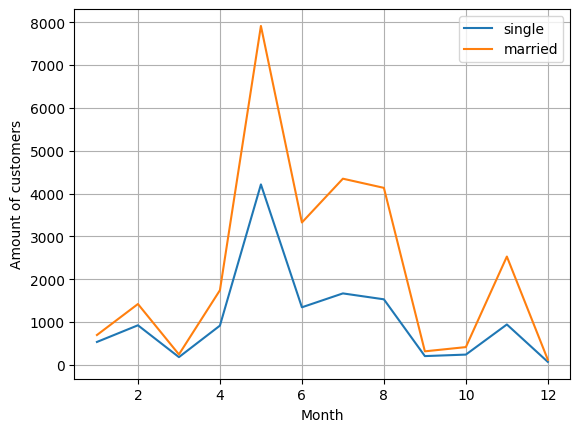

In [90]:
plt.figure()

plt.plot(data_sngl['month'], data_sngl['count'])
plt.plot(data_marr['month'], data_marr['count'])
plt.xlabel('Month')
plt.ylabel('Amount of customers')
plt.legend(['single', 'married'])
plt.grid(1)
plt.show()

### Demographic Analysis: Marital Status
**What we're analyzing**: Contact distribution by marital status over time
**Why important**: Understand if targeting varies by demographic groups
**Key findings**:
- Married individuals receive more contacts consistently
- Single individuals show similar seasonal patterns
- Helps identify potential targeting strategies
- Reveals demographic reach of marketing campaigns

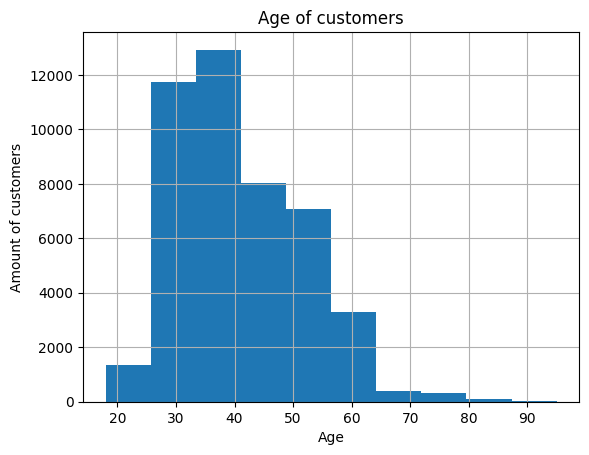

In [91]:
# Age group analysis

plt.figure()
plt.hist(df['age'], bins=10)
plt.title('Age of customers')
plt.xlabel('Age')
plt.ylabel('Amount of customers')
plt.grid(1)
plt.show()

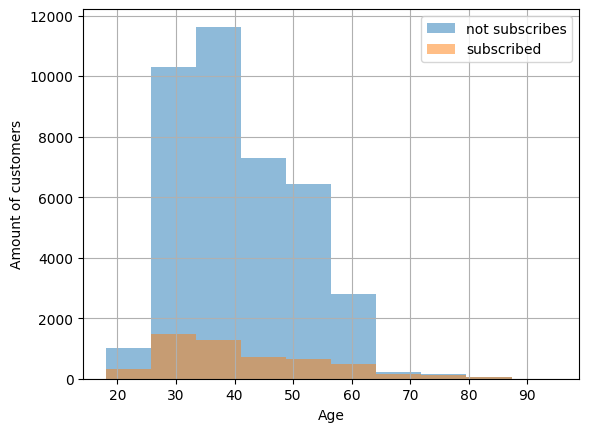

In [92]:
plt.figure()
plt.hist(df['age'][df['y'] == 'no'], alpha=0.5)
plt.hist(df['age'][df['y'] == 'yes'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Amount of customers')
plt.grid(1)
plt.legend(['not subscribes', 'subscribed'])
plt.show()

In [93]:
# Target encoding
df['subscribed'] = df['y'].map({'yes':1, 'no':0})
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,subscribed
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,5,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,5,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,5,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,5,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,5,198,1,-1,0,unknown,no,0


In [94]:
df[['y', 'subscribed']][1515:1525] # check

,y,subscribed
1515,no,0
1516,no,0
1517,no,0
1518,no,0
1519,no,0
1520,yes,1
1521,no,0
1522,no,0
1523,no,0
1524,no,0


In [95]:
data_age_common = df.groupby('age').size().reset_index(name='count')
data_age_common

,age,count
0,18,12
1,19,35
2,20,50
3,21,79
4,22,129
...,...,...
72,90,2
73,92,2
74,93,2
75,94,1


In [96]:
data_age_cust = df[df['subscribed'] == 1].groupby('age').size().reset_index(name='count')
data_age_cust

,age,count
0,18,7
1,19,11
2,20,15
3,21,22
4,22,40
...,...,...
69,87,3
70,90,2
71,92,2
72,93,2


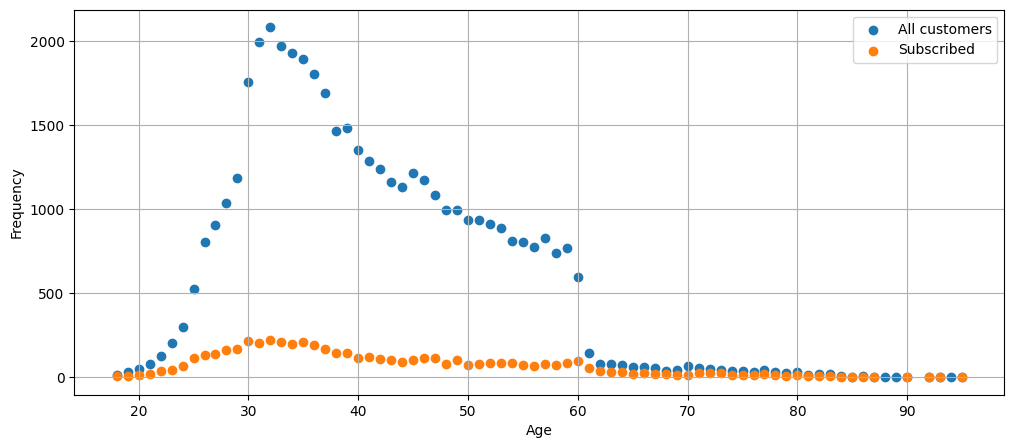

In [97]:
plt.figure(figsize=(12,5))
plt.scatter(data_age_common['age'], data_age_common['count'], label='All customers')
plt.scatter(data_age_cust['age'], data_age_cust['count'], label='Subscribed')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(1)
plt.legend()
plt.show()

### Age Distribution Analysis
**What we're analyzing**: Customer age patterns and subscription behavior
**Why important**: Age is often a key predictor in financial products
**Key findings**:
- Age distribution is right-skewed (most customers 25-55)
- Subscribers show slightly different age patterns
- Younger and older demographics may have different response rates
- Informs age-based targeting strategies

In [98]:
data_dur_yes = df['duration'][df['subscribed'] == 1]
data_dur_no = df['duration'][df['subscribed'] == 0]
data_dur_yes.head()

83     1042
86     1467
87     1389
129     579
168     673
Name: duration, dtype: int64

In [99]:
data_dur_no.head()

0    261
1    151
2     76
3     92
4    198
Name: duration, dtype: int64

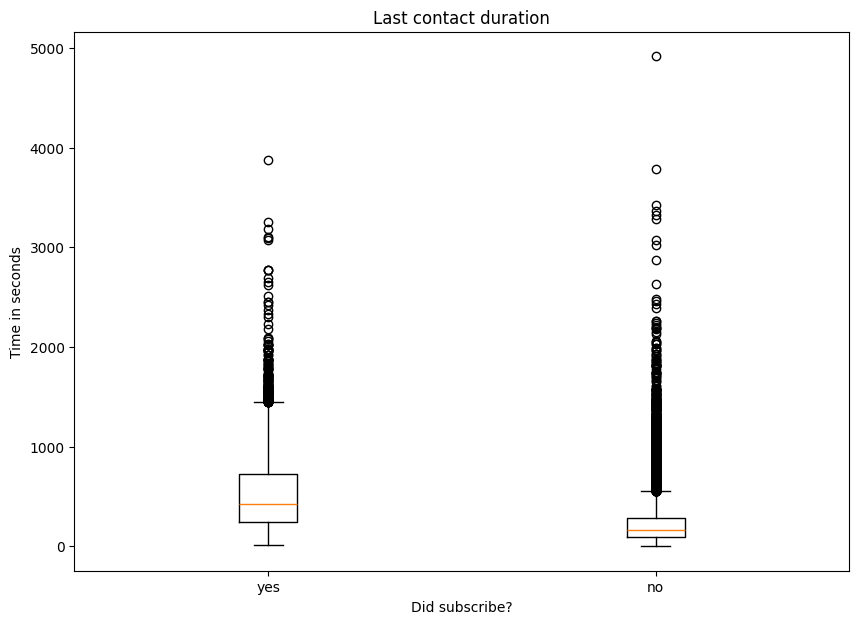

In [100]:
plt.figure(figsize=(10,7))
plt.boxplot([data_dur_yes, data_dur_no])
plt.title("Last contact duration")
plt.xlabel("Did subscribe?")
plt.ylabel('Time in seconds')
plt.xticks([1,2], ['yes', 'no'])
plt.show()

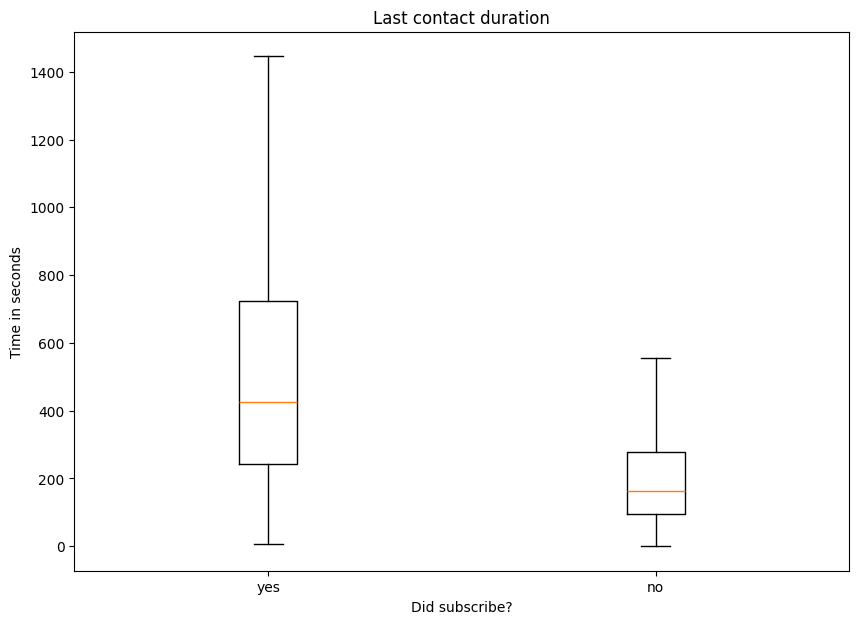

In [101]:
# Without emissions
plt.figure(figsize=(10,7))
plt.boxplot([data_dur_yes, data_dur_no], showfliers=False)
plt.title("Last contact duration")
plt.xlabel("Did subscribe?")
plt.ylabel('Time in seconds')
plt.xticks([1,2], ['yes', 'no'])
plt.show()

### Contact Duration Analysis
**What we're analyzing**: Relationship between call duration and subscription
**Why important**: Call duration may indicate customer engagement level
**Key findings**:
- Subscribers have significantly longer call durations
- Duration shows strong correlation with subscription (0.39 - the correlation matrix will be shown below) 
- **!!! Data leakage concern**: Duration is only known after call
- **Decision**: Remove duration to avoid target leakage in modeling

In [102]:
# Jobs

data_jobs = df['job'].value_counts().reset_index(name='count')
data_jobs

,job,count
0,blue-collar,9732
1,management,9458
2,technician,7597
3,admin.,5171
4,services,4154
5,retired,2264
6,self-employed,1579
7,entrepreneur,1487
8,unemployed,1303
9,housemaid,1240


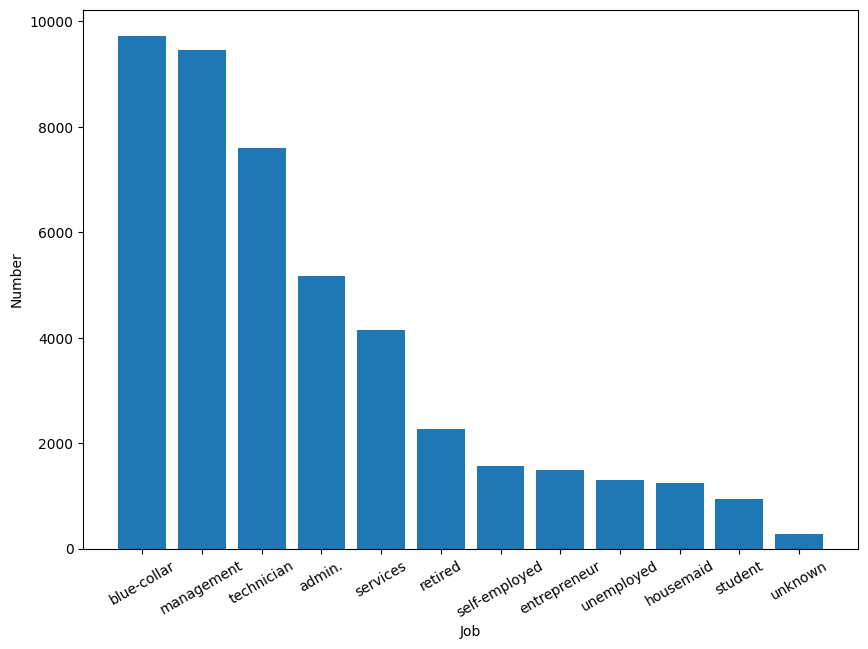

In [103]:
plt.figure(figsize=(10,7))
plt.bar(data_jobs['job'], data_jobs['count'])
plt.xlabel('Job')
plt.ylabel('Number')
plt.xticks(rotation=30)
plt.show()

In [104]:
df['job'][df['subscribed'] == 1].value_counts().reset_index(name='yes').sort_values(by='yes', ascending=True)

,job,yes
11,unknown,34
10,housemaid,109
9,entrepreneur,123
8,self-employed,187
7,unemployed,202
6,student,269
5,services,369
4,retired,516
3,admin.,631
2,blue-collar,708


In [105]:
df['job'][df['subscribed'] == 0].value_counts().reset_index(name='no').sort_values(by='no',ascending=False)

,job,no
0,blue-collar,9024
1,management,8157
2,technician,6757
3,admin.,4540
4,services,3785
5,retired,1748
6,self-employed,1392
7,entrepreneur,1364
8,housemaid,1131
9,unemployed,1101


In [106]:
data_jobs_comm = pd.crosstab(df['job'], df['y']).reset_index().sort_values(by='no', ascending=False)
data_jobs_comm.head()

y,job,no,yes
1,blue-collar,9024,708
4,management,8157,1301
9,technician,6757,840
0,admin.,4540,631
7,services,3785,369


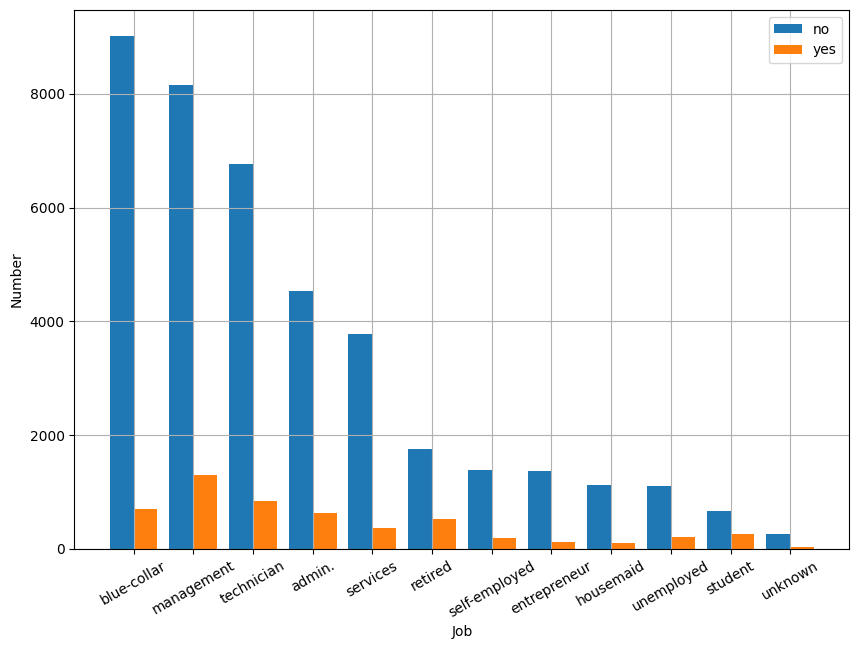

In [107]:
plt.figure(figsize=(10,7))
n_ticks = np.arange(len(data_jobs_comm['no']))

offset = 0.2
w = 0.4

plt.bar(n_ticks - offset, data_jobs_comm['no'], width=w, label='no')
plt.bar(n_ticks + offset, data_jobs_comm['yes'], width=w, label='yes')

plt.xticks(n_ticks, data_jobs_comm['job'], rotation=30)
plt.xlabel('Job')
plt.ylabel('Number')
plt.legend()
plt.grid(1)
plt.show()

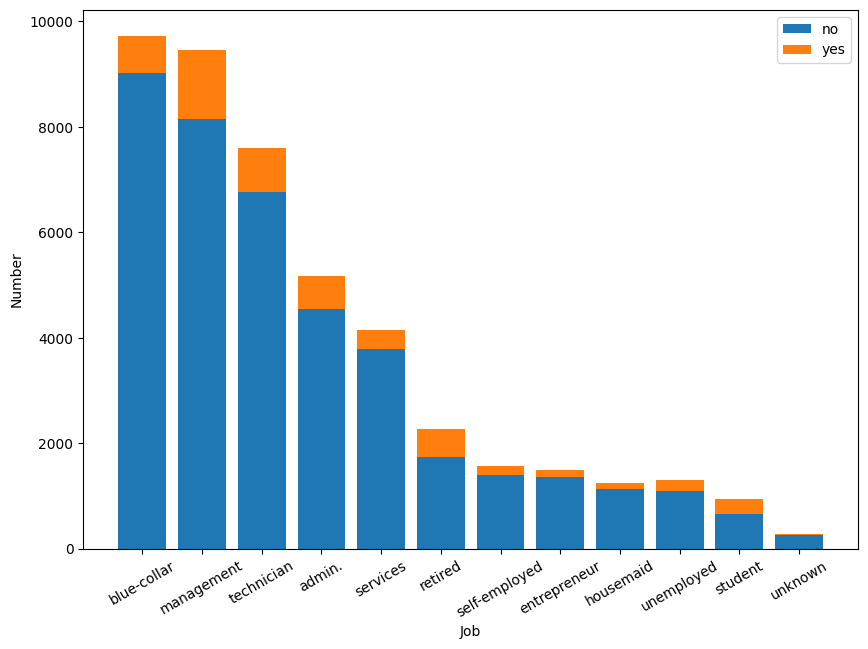

In [108]:
plt.figure(figsize=(10,7))
plt.bar(data_jobs_comm['job'], data_jobs_comm['no'], label='no')
plt.bar(data_jobs_comm['job'], data_jobs_comm['yes'], bottom=data_jobs_comm['no'], label='yes')
plt.legend()
plt.xticks(rotation=30)
plt.xlabel('Job')
plt.ylabel('Number')
plt.show()

In [109]:
data_jobs_comm_norm = pd.crosstab(df['job'], df['y'], normalize='index').reset_index().sort_values(by='no', ascending=False)
data_jobs_comm_norm.head()

y,job,no,yes
1,blue-collar,0.927250,0.072750
2,entrepreneur,0.917283,0.082717
3,housemaid,0.912097,0.087903
7,services,0.911170,0.088830
9,technician,0.889430,0.110570


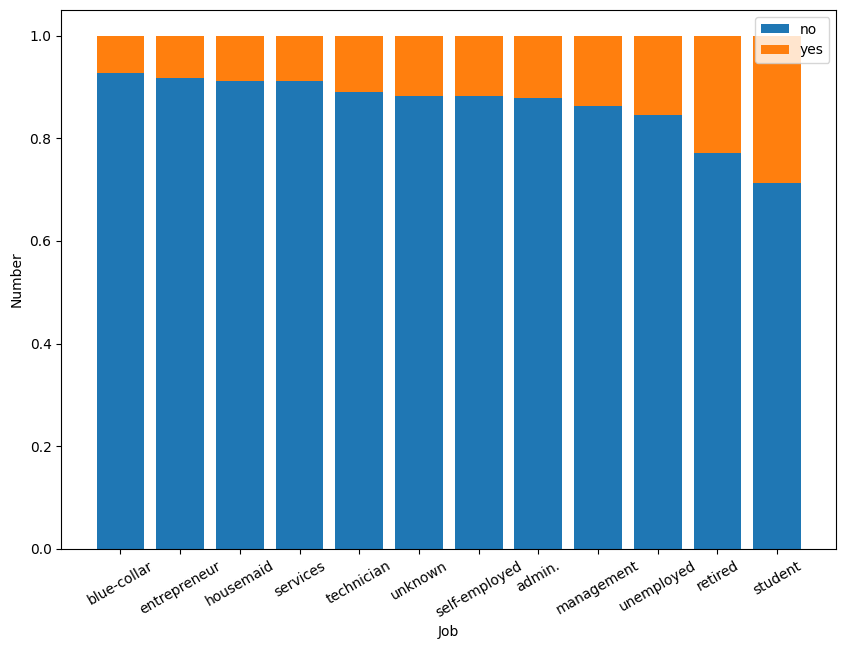

In [110]:
plt.figure(figsize=(10,7))
plt.bar(data_jobs_comm_norm['job'], data_jobs_comm_norm['no'], label='no')
plt.bar(data_jobs_comm_norm['job'], data_jobs_comm_norm['yes'], bottom=data_jobs_comm_norm['no'], label='yes')
plt.legend()
plt.xticks(rotation=30)
plt.xlabel('Job')
plt.ylabel('Number')
plt.show()

### Employment Analysis
**What we're analyzing**: Job type distribution and subscription rates
**Why important**: Employment status affects financial decision-making
**Key findings**:
- Management and blue-collar workers are most contacted
- Management shows highest subscription numbers
- Students and retired have higher subscription rates proportionally
- Job type is a strong predictor for targeting

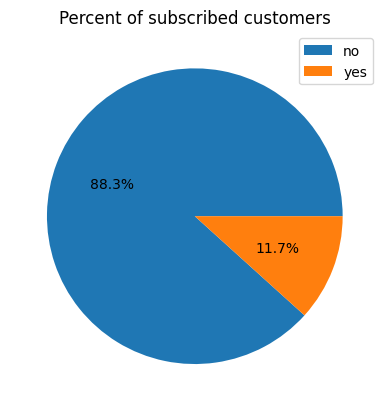

In [111]:
plt.figure()

plt.pie(df['y'].value_counts(), autopct='%1.1f%%')
plt.title('Percent of subscribed customers')
plt.legend(['no', 'yes'])
plt.show()

### Class Distribution Analysis
**What we're analyzing**: Target variable balance
**Why important**: Identifies class imbalance issues
**Key findings**:
- **Severe class imbalance**: 88.3% non-subscribers vs 11.7% subscribers
- Imbalance affects model training and evaluation
- Need for balanced class weights or sampling techniques
- Accuracy alone is not a good metric for this dataset

In [112]:
# Data Preprocessing
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,subscribed
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,5,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,5,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,5,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,5,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,5,198,1,-1,0,unknown,no,0


In [113]:
df.isnull().sum()

age           0
job           0
marital       0
education     0
default       0
balance       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
y             0
subscribed    0
dtype: int64

In [114]:
df['default'] = df['default'].map({'yes':1, 'no':0})
df['housing'] = df['housing'].map({'yes':1, 'no':0})
df['loan'] = df['loan'].map({'yes':1, 'no':0})
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,subscribed
0,58,management,married,tertiary,0,2143,1,0,unknown,5,5,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,0,29,1,0,unknown,5,5,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,5,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,0,1506,1,0,unknown,5,5,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,0,1,0,0,unknown,5,5,198,1,-1,0,unknown,no,0


In [115]:
df['marital'].unique()

array(['married', 'single', 'divorced'], dtype=object)

In [116]:
df['contact'].unique()

array(['unknown', 'cellular', 'telephone'], dtype=object)

In [117]:
df['poutcome'].unique()

array(['unknown', 'failure', 'other', 'success'], dtype=object)

In [118]:
df['job'].unique()

array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin.', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

In [119]:
df['education'].unique()

array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object)

In [120]:
df = df.drop('contact', axis=1)
df = pd.get_dummies(df, columns=['marital'], drop_first=True)
df.head()

,age,job,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,poutcome,y,subscribed,marital_married,marital_single
0,58,management,tertiary,0,2143,1,0,5,5,261,1,-1,0,unknown,no,0,True,False
1,44,technician,secondary,0,29,1,0,5,5,151,1,-1,0,unknown,no,0,False,True
2,33,entrepreneur,secondary,0,2,1,1,5,5,76,1,-1,0,unknown,no,0,True,False
3,47,blue-collar,unknown,0,1506,1,0,5,5,92,1,-1,0,unknown,no,0,True,False
4,33,unknown,unknown,0,1,0,0,5,5,198,1,-1,0,unknown,no,0,False,True


In [121]:
df = df.drop('y', axis=1)
df.head()

,age,job,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,poutcome,subscribed,marital_married,marital_single
0,58,management,tertiary,0,2143,1,0,5,5,261,1,-1,0,unknown,0,True,False
1,44,technician,secondary,0,29,1,0,5,5,151,1,-1,0,unknown,0,False,True
2,33,entrepreneur,secondary,0,2,1,1,5,5,76,1,-1,0,unknown,0,True,False
3,47,blue-collar,unknown,0,1506,1,0,5,5,92,1,-1,0,unknown,0,True,False
4,33,unknown,unknown,0,1,0,0,5,5,198,1,-1,0,unknown,0,False,True


In [122]:
df['marital_married'] = df['marital_married'].map({True:1, False:0})
df['marital_single'] = df['marital_single'].map({True:1, False:0})
df.head()

,age,job,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,poutcome,subscribed,marital_married,marital_single
0,58,management,tertiary,0,2143,1,0,5,5,261,1,-1,0,unknown,0,1,0
1,44,technician,secondary,0,29,1,0,5,5,151,1,-1,0,unknown,0,0,1
2,33,entrepreneur,secondary,0,2,1,1,5,5,76,1,-1,0,unknown,0,1,0
3,47,blue-collar,unknown,0,1506,1,0,5,5,92,1,-1,0,unknown,0,1,0
4,33,unknown,unknown,0,1,0,0,5,5,198,1,-1,0,unknown,0,0,1


In [123]:
df['job_freq'] = df['job'].map(df['job'].value_counts(normalize=True))
df['education_freq'] = df['education'].map(df['education'].value_counts(normalize=True))
df['poutcome_freq'] = df['poutcome'].map(df['poutcome'].value_counts(normalize=True))

df.head()

,age,job,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,poutcome,subscribed,marital_married,marital_single,job_freq,education_freq,poutcome_freq
0,58,management,tertiary,0,2143,1,0,5,5,261,1,-1,0,unknown,0,1,0,0.209197,0.294198,0.817478
1,44,technician,secondary,0,29,1,0,5,5,151,1,-1,0,unknown,0,0,1,0.168034,0.513194,0.817478
2,33,entrepreneur,secondary,0,2,1,1,5,5,76,1,-1,0,unknown,0,1,0,0.032890,0.513194,0.817478
3,47,blue-collar,unknown,0,1506,1,0,5,5,92,1,-1,0,unknown,0,1,0,0.215257,0.041074,0.817478
4,33,unknown,unknown,0,1,0,0,5,5,198,1,-1,0,unknown,0,0,1,0.006370,0.041074,0.817478


In [124]:
df.dtypes

age                  int64
job                 object
education           object
default              int64
balance              int64
housing              int64
loan                 int64
day                  int64
month                int32
duration             int64
campaign             int64
pdays                int64
previous             int64
poutcome            object
subscribed           int64
marital_married      int64
marital_single       int64
job_freq           float64
education_freq     float64
poutcome_freq      float64
dtype: object

In [125]:
df['month'] = df['month'].astype('int64')

In [126]:
df.isna().sum()

age                0
job                0
education          0
default            0
balance            0
housing            0
loan               0
day                0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome           0
subscribed         0
marital_married    0
marital_single     0
job_freq           0
education_freq     0
poutcome_freq      0
dtype: int64

In [127]:
df.head()


,age,job,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,poutcome,subscribed,marital_married,marital_single,job_freq,education_freq,poutcome_freq
0,58,management,tertiary,0,2143,1,0,5,5,261,1,-1,0,unknown,0,1,0,0.209197,0.294198,0.817478
1,44,technician,secondary,0,29,1,0,5,5,151,1,-1,0,unknown,0,0,1,0.168034,0.513194,0.817478
2,33,entrepreneur,secondary,0,2,1,1,5,5,76,1,-1,0,unknown,0,1,0,0.032890,0.513194,0.817478
3,47,blue-collar,unknown,0,1506,1,0,5,5,92,1,-1,0,unknown,0,1,0,0.215257,0.041074,0.817478
4,33,unknown,unknown,0,1,0,0,5,5,198,1,-1,0,unknown,0,0,1,0.006370,0.041074,0.817478


In [128]:
df.shape

(45211, 20)

In [129]:
# Correlation

numeric_df = df.select_dtypes(include=[np.number])
numeric_df.head()

,age,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,subscribed,marital_married,marital_single,job_freq,education_freq,poutcome_freq
0,58,0,2143,1,0,5,5,261,1,-1,0,0,1,0,0.209197,0.294198,0.817478
1,44,0,29,1,0,5,5,151,1,-1,0,0,0,1,0.168034,0.513194,0.817478
2,33,0,2,1,1,5,5,76,1,-1,0,0,1,0,0.032890,0.513194,0.817478
3,47,0,1506,1,0,5,5,92,1,-1,0,0,1,0,0.215257,0.041074,0.817478
4,33,0,1,0,0,5,5,198,1,-1,0,0,0,1,0.006370,0.041074,0.817478


In [130]:
corr_matrix = numeric_df.corr()

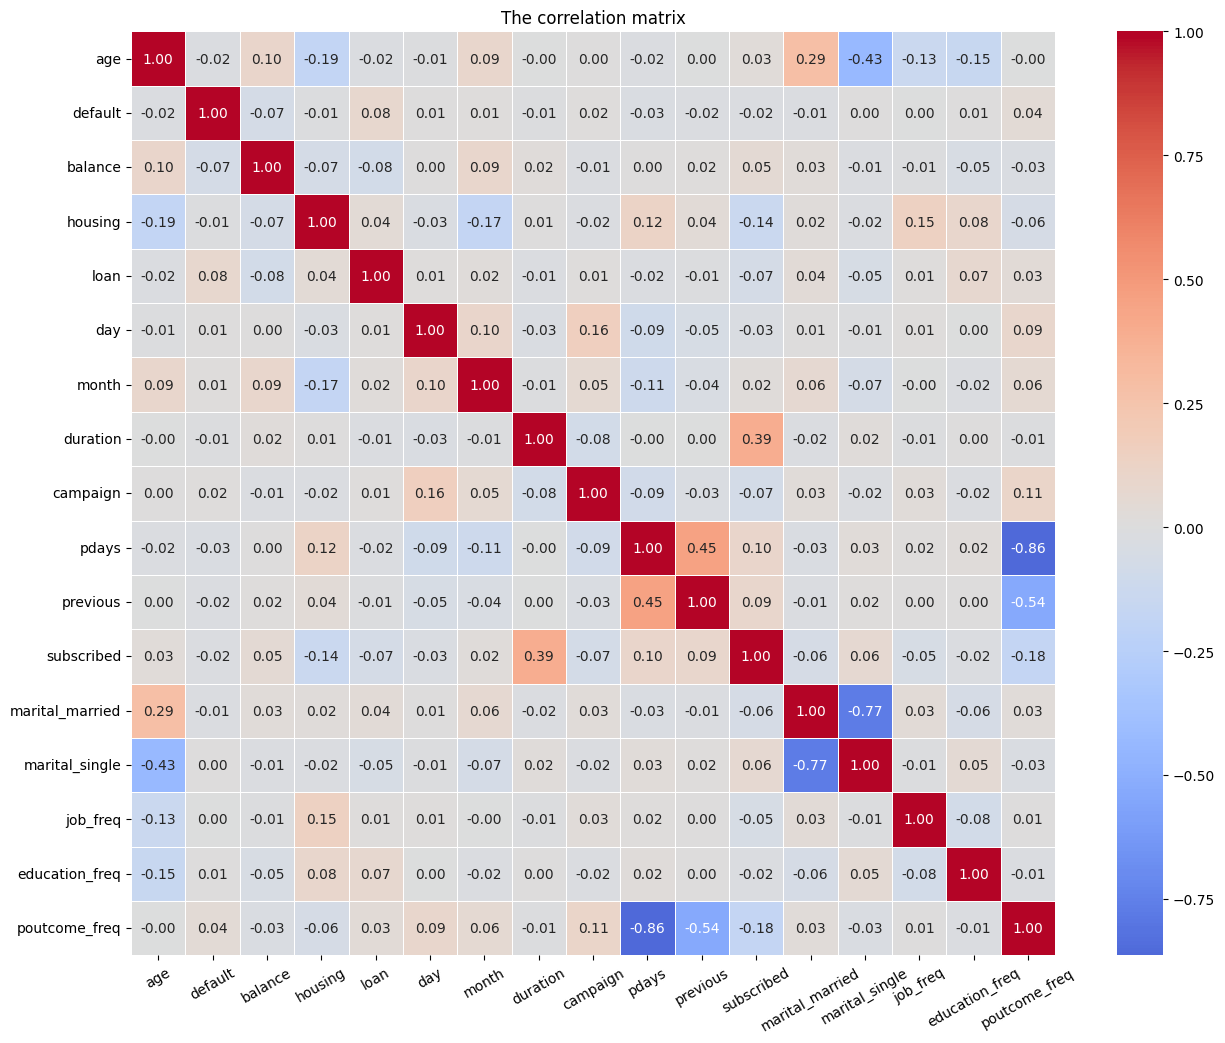

In [131]:
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('The correlation matrix')
plt.xticks(rotation=30)
plt.show()

In [132]:
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"\nFound {len(high_corr_pairs)} pairs with correlation > 0.5:")
for pair in high_corr_pairs[:10]:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")


Found 3 pairs with correlation > 0.5:
pdays - poutcome_freq: -0.864
previous - poutcome_freq: -0.535
marital_married - marital_single: -0.772


In [133]:
numeric_df = numeric_df.drop('poutcome_freq', axis=1)
numeric_df = numeric_df.drop('marital_married', axis=1)

print(numeric_df.shape)
numeric_df.head()

(45211, 15)


,age,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,subscribed,marital_single,job_freq,education_freq
0,58,0,2143,1,0,5,5,261,1,-1,0,0,0,0.209197,0.294198
1,44,0,29,1,0,5,5,151,1,-1,0,0,1,0.168034,0.513194
2,33,0,2,1,1,5,5,76,1,-1,0,0,0,0.032890,0.513194
3,47,0,1506,1,0,5,5,92,1,-1,0,0,0,0.215257,0.041074
4,33,0,1,0,0,5,5,198,1,-1,0,0,1,0.006370,0.041074


In [134]:
duration_corr = numeric_df['duration'].corr(numeric_df['subscribed'])
duration_corr # leakage ???!!!

np.float64(0.39452101589456184)

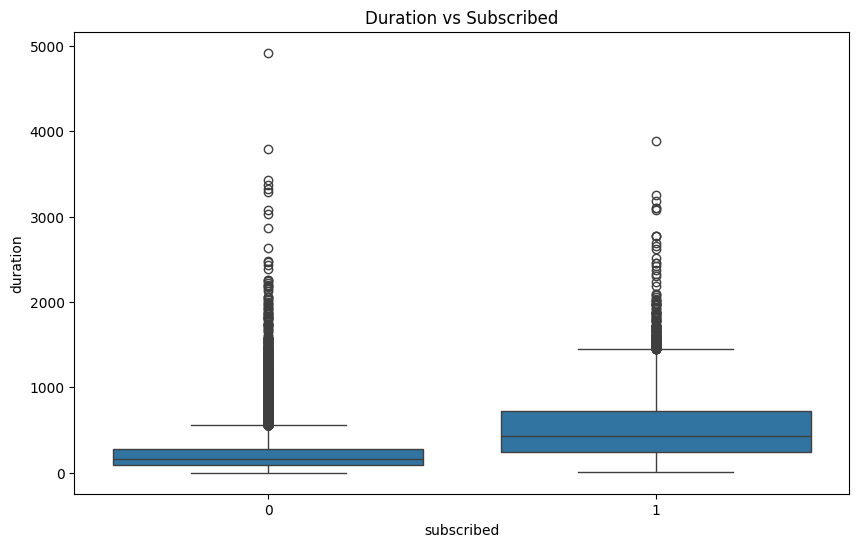

In [135]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='subscribed', y='duration', data=numeric_df)
plt.title('Duration vs Subscribed')
plt.show()

In [136]:
numeric_df = numeric_df.drop('duration', axis=1)
numeric_df.head()

,age,default,balance,housing,loan,day,month,campaign,pdays,previous,subscribed,marital_single,job_freq,education_freq
0,58,0,2143,1,0,5,5,1,-1,0,0,0,0.209197,0.294198
1,44,0,29,1,0,5,5,1,-1,0,0,1,0.168034,0.513194
2,33,0,2,1,1,5,5,1,-1,0,0,0,0.032890,0.513194
3,47,0,1506,1,0,5,5,1,-1,0,0,0,0.215257,0.041074
4,33,0,1,0,0,5,5,1,-1,0,0,1,0.006370,0.041074


In [137]:
# Outliers detection

def IQR_bounds (col):
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return lower, upper

In [138]:
low,high = IQR_bounds('balance')

outliners = numeric_df[(numeric_df['balance'] < low) |
    (numeric_df['balance'] > high)]

outliners

,age,default,balance,housing,loan,day,month,campaign,pdays,previous,subscribed,marital_single,job_freq,education_freq
34,51,0,10635,1,0,5,5,1,-1,0,0,0,0.209197,0.294198
65,51,0,6530,1,0,5,5,1,-1,0,0,0,0.209197,0.294198
69,35,0,12223,1,1,5,5,1,-1,0,0,1,0.215257,0.513194
70,57,0,5935,1,1,5,5,1,-1,0,0,0,0.215257,0.513194
186,40,0,4384,1,0,5,5,1,-1,0,0,0,0.091880,0.041074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45164,35,0,4655,0,0,9,11,2,-1,0,0,0,0.091880,0.294198
45181,46,0,6879,0,0,15,11,2,118,3,0,0,0.215257,0.513194
45185,60,0,4256,1,0,16,11,1,92,4,1,0,0.091880,0.294198
45191,75,0,3810,1,0,16,11,1,183,1,1,0,0.050076,0.294198


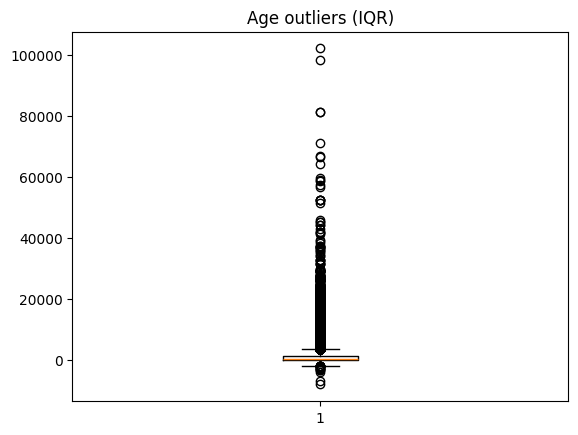

In [139]:
plt.boxplot(numeric_df['balance'])
plt.title("Age outliers (IQR)")
plt.show()

In [140]:
numeric_df.describe() # significant emissions

,age,default,balance,housing,loan,day,month,campaign,pdays,previous,subscribed,marital_single,job_freq,education_freq
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,0.018027,1362.272058,0.555838,0.160226,15.806419,6.144655,2.763841,40.197828,0.580323,0.116985,0.282896,0.146721,0.374570
std,10.618762,0.133049,3044.765829,0.496878,0.366820,8.322476,2.408034,3.098021,100.128746,2.303441,0.321406,0.450411,0.069829,0.154496
min,18.000000,0.000000,-8019.000000,0.000000,0.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000,0.000000,0.006370,0.041074
25%,33.000000,0.000000,72.000000,0.000000,0.000000,8.000000,5.000000,1.000000,-1.000000,0.000000,0.000000,0.000000,0.091880,0.294198
50%,39.000000,0.000000,448.000000,1.000000,0.000000,16.000000,6.000000,2.000000,-1.000000,0.000000,0.000000,0.000000,0.168034,0.513194
75%,48.000000,0.000000,1428.000000,1.000000,0.000000,21.000000,8.000000,3.000000,-1.000000,0.000000,0.000000,1.000000,0.209197,0.513194
max,95.000000,1.000000,102127.000000,1.000000,1.000000,31.000000,12.000000,63.000000,871.000000,275.000000,1.000000,1.000000,0.215257,0.513194


In [141]:
scaler = RobustScaler()
df_num_scaled = numeric_df.copy()
df_num_scaled = scaler.fit_transform(df_num_scaled)

In [142]:
df_num_scaled

array([[ 1.26666667,  0.        ,  1.25      , ...,  0.        ,
         0.35086727, -1.        ],
       [ 0.33333333,  0.        , -0.30899705, ...,  1.        ,
         0.        ,  0.        ],
       [-0.4       ,  0.        , -0.32890855, ...,  0.        ,
        -1.15196078,  0.        ],
       ...,
       [ 2.2       ,  0.        ,  3.88421829, ...,  0.        ,
        -1.00546757,  0.        ],
       [ 1.2       ,  0.        ,  0.16224189, ...,  0.        ,
         0.4025264 ,  0.        ],
       [-0.13333333,  0.        ,  1.86061947, ...,  0.        ,
        -1.15196078,  0.        ]], shape=(45211, 14))

## Data Preprocessing

### Feature Engineering Strategy
**Objective**: Prepare clean, numerical features for machine learning

**Steps performed**:
1. **Binary encoding**: Convert yes/no variables to 0/1
2. **One-hot encoding**: Transform categorical variables
3. **Frequency encoding**: Replace categories with occurrence frequencies
4. **Correlation analysis**: Remove highly correlated features to avoid multicollinearity
5. **Data leakage removal**: Eliminate duration variable
6. **Outlier handling**: Use RobustScaler for scaling because there are a lot of outliers in the data

**Key decisions**:
- Dropped 'contact' column (limited predictive value)
- Removed highly correlated features (poutcome_freq, marital_married)
- Used frequency encoding for high-cardinality categorical variables

In [143]:
df_num_scaled = pd.DataFrame(
    scaler.fit_transform(numeric_df),
    columns=numeric_df.columns,
    index=numeric_df.index
)
type(df_num_scaled)

pandas.core.frame.DataFrame

## Model Building

### Algorithm Selection: Logistic Regression
**Why Logistic Regression**:
- **Interpretability**: Coefficients show feature importance
- **Efficiency**: Fast training and prediction
- **Baseline**: Provides solid baseline for comparison
- **Probabilistic**: Outputs probability scores
- **Linear relationships**: Works well with engineered features

### Model Configuration
- **Class weight**: 'balanced' to handle class imbalance
- **Max iterations**: 1000 for convergence
- **Random state**: 42 for reproducibility
- **Train-test split**: 80/20 with stratification

In [144]:
df_num_scaled.head() # scaled dataframe

,age,default,balance,housing,loan,day,month,campaign,pdays,previous,subscribed,marital_single,job_freq,education_freq
0,1.266667,0.0,1.250000,0.0,0.0,-0.846154,-0.333333,-0.5,0.0,0.0,0.0,0.0,0.350867,-1.000000
1,0.333333,0.0,-0.308997,0.0,0.0,-0.846154,-0.333333,-0.5,0.0,0.0,0.0,1.0,0.000000,0.000000
2,-0.400000,0.0,-0.328909,0.0,1.0,-0.846154,-0.333333,-0.5,0.0,0.0,0.0,0.0,-1.151961,0.000000
3,0.533333,0.0,0.780236,0.0,0.0,-0.846154,-0.333333,-0.5,0.0,0.0,0.0,0.0,0.402526,-2.155843
4,-0.400000,0.0,-0.329646,-1.0,0.0,-0.846154,-0.333333,-0.5,0.0,0.0,0.0,1.0,-1.378017,-2.155843


In [145]:
df_num_scaled["subscribed"].value_counts() # the target is not scaled

subscribed
0.0    39922
1.0     5289
Name: count, dtype: int64

In [146]:
X = df_num_scaled.drop(columns=['subscribed'])
y = numeric_df['subscribed'] # initial target

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [148]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

In [149]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).T
report_df

,precision,recall,f1-score,support
0,0.933987,0.620163,0.745390,7985.000000
1,0.189254,0.669187,0.295061,1058.000000
accuracy,0.625898,0.625898,0.625898,0.625898
macro avg,0.561621,0.644675,0.520226,9043.000000
weighted avg,0.846856,0.625898,0.692703,9043.000000


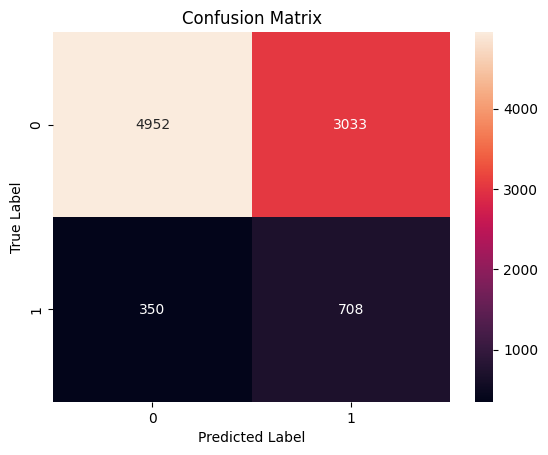

In [150]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cbar=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [151]:
roc_auc_score(y_test, y_proba)

0.702209601414751

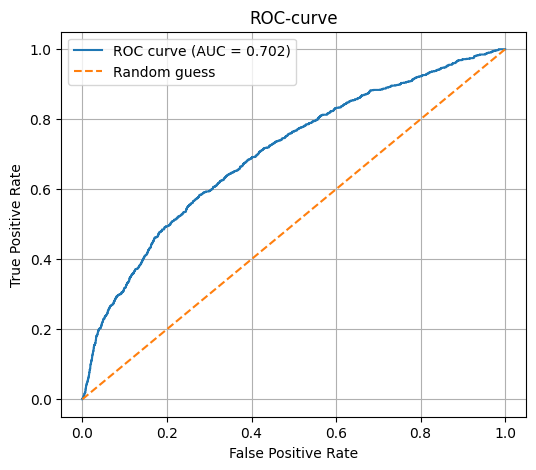

In [152]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle="--", label='Random guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend()
plt.grid(1)

plt.show()

## Model Evaluation

### Performance Metrics Analysis
**Metrics Used**:
- **Precision**: Ability to avoid false positives
- **Recall**: Ability to capture all actual positives  
- **F1-Score**: Harmonic mean of precision and recall
- **AUC-ROC**: Overall discriminative ability
- **Confusion Matrix**: Detailed error analysis

**Key Results**:
- **Overall Accuracy**: 62.6% (misleading due to class imbalance)
- **Class 0 (No Subscribe)**: High precision (93.3%), low recall (62%)
- **Class 1 (Subscribe)**: Low precision (18.9%), high recall (66.9%)
- **AUC-ROC**: 0.702 (fair discriminative ability)

**Interpretation**:
- Model is conservative in predicting subscriptions
- High recall for subscribers means we capture most potential customers
- Low precision means many false positives (marketing cost)
- AUC of 0.702 indicates moderate predictive power

## Conclusion

### Model Performance Summary
**Strengths**:
- Good recall for subscribers (66.9%) - captures most potential customers
- Fair AUC score (0.702) - better than random guessing
- Interpretable model with clear feature importance
- Handles class imbalance appropriately

**Limitations**:
- Low precision for subscribers (18.9%) - many false positives
- Overall accuracy inflated by class imbalance
- Linear model may miss complex relationships
- Feature engineering could be more sophisticated

### Business Impact
- **Current model**: Identifies 67% of potential subscribers but with high marketing waste
- **Recommendation**: Use as initial filter, combine with more complex models
- **Next steps**: Try ensemble methods, feature selection, threshold optimization

### Key Learnings
- Data leakage prevention is crucial (duration removal)
- Class imbalance requires careful metric selection
- Simple models provide valuable baselines
- EDA drives important preprocessing decisions